# Sales Data Analyst Project

## Project Overview
This project analyzes a real-world sales lead dataset from raw data preparation through exploratory data analysis, statistical analysis, classification modelling, feature importance, and preparation for Power BI reporting.

## Objective
- Clean and validate the raw sales lead data.
- Handle missing values and duplicate records.
- Standardize and group categorical values for analysis.
- Create useful date/time and business features.
- Perform EDA, distribution analysis, cross-analysis, and IQR-based outlier checks.
- Build classification models to study lead conversion.
- Compare model metrics and inspect feature importance.
- Prepare the final cleaned dataset for Power BI.

## Tools Used
- Python
- Pandas and NumPy
- Matplotlib and Seaborn
- Scikit-learn
- Jupyter Notebook
- Power BI (final reporting stage)

## Project Workflow
Raw Data → Data Quality Check → Missing Value Handling → Duplicate Removal → Text/Status Standardization → Category Grouping → Date/Time Feature Engineering → EDA → Statistical Analysis → IQR/Outlier Analysis → ML Feature Preparation → Train/Test Split → Classification Models → Model Evaluation → Feature Importance → Final Cleaned CSV → Power BI

## Documentation Note
Insights below the analysis and visualizations are descriptive findings from this dataset. They do not imply causation unless explicitly supported by the analysis.


# 1.Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2.Load Dataset

In [2]:
df = pd.read_csv("project_sales.csv")
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (7422, 7)


,Created,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,NaN,Website,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,Sales-Agent-10,NaN,Mode-5,Open


### Initial Dataset Understanding

The reference analysis starts with the `project_sales.csv` sales-lead dataset containing **7,422 records and 7 variables**.

The main business fields are:

- `Created` – lead creation date/time
- `Product_ID` – product identifier
- `Source` – lead source
- `Sales_Agent` – assigned sales representative
- `Location` – customer/lead location
- `Delivery_Mode` – delivery/contact mode
- `Status` – lead status

The original reference analysis identifies missing values in Product_ID, Source, Sales_Agent and Location, while Delivery_Mode and Status have no missing values at the initial stage.

# 3. Dataset Information

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nBasic Information:")
df.info()


Rows: 7422
Columns: 7

Column Names:
['Created', 'Product_ID', 'Source', 'Sales_Agent', 'Location', 'Delivery_Mode', 'Status']

Data Types:


,Data Type
Created,str
Product_ID,float64
Source,str
Sales_Agent,str
Location,str
Delivery_Mode,str
Status,str



Basic Information:
<class 'pandas.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Created        7422 non-null   str    
 1   Product_ID     7364 non-null   float64
 2   Source         7405 non-null   str    
 3   Sales_Agent    7399 non-null   str    
 4   Location       7364 non-null   str    
 5   Delivery_Mode  7422 non-null   str    
 6   Status         7422 non-null   str    
dtypes: float64(1), str(6)
memory usage: 892.4 KB


# 4.Basic Statistical Summary

In [4]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Created,7422,6752,15-10-2018 10:36,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_ID,7364.0,NaN,NaN,NaN,15.947311,6.072937,0.0,12.0,18.0,19.0,28.0
Source,7405,25,Call,2547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales_Agent,7399,12,Sales-Agent-4,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,7364,17,Other Locations,2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_Mode,7422,5,Mode-5,2975,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,7422,11,Junk Lead,1536,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Observation
Product_ID appears as a numeric column in the raw dataset because missing values cause it to be represented as a floating-point type. It is actually a product identifier, so it should be treated as a categorical field rather than a continuous numeric measure.

# 5. Missing Value Analysis

In [5]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})
display(missing_summary)

,Missing Count,Missing Percentage
Created,0,0.00
Product_ID,58,0.78
Source,17,0.23
Sales_Agent,23,0.31
Location,58,0.78
Delivery_Mode,0,0.00
Status,0,0.00


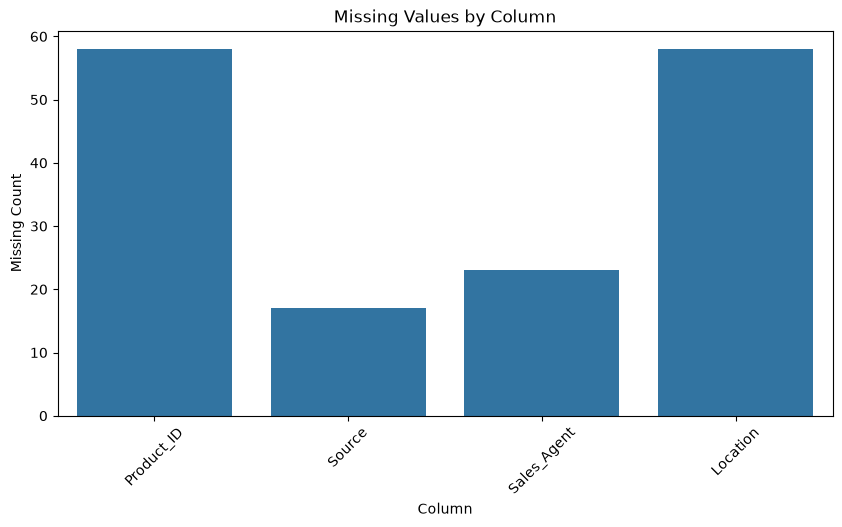

In [6]:
missing_only = missing_summary[missing_summary["Missing Count"] > 0]
plt.figure(figsize=(10, 5))
sns.barplot(
    x=missing_only.index,
    y=missing_only["Missing Count"]
)
plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Count")
plt.xticks(rotation=45)
plt.show()

### Missing Value Insight
The reference analysis identifies missing values mainly in **Product_ID, Source, Sales_Agent and Location**.

# 6. Duplicate Analysis

In [7]:
duplicate_count = df.duplicated().sum()

print("Exact Duplicate Rows:", duplicate_count)
print("Duplicate Percentage:", round(duplicate_count / len(df) * 100, 2), "%")

Exact Duplicate Rows: 11
Duplicate Percentage: 0.15 %


The reference workflow reports **11 exact duplicate rows**, approximately **0.15%** of the original dataset.

# 7. Categorical / Unique Value Analysis

In [8]:
categorical_columns = [
    "Product_ID",
    "Source",
    "Sales_Agent",
    "Location",
    "Delivery_Mode",
    "Status"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print("Unique Values:", df[col].nunique(dropna=True))
    display(df[col].value_counts(dropna=False).head(20))
    


--- Product_ID ---
Unique Values: 29


Product_ID
18.0    1711
15.0    1518
19.0    1189
9.0      992
27.0     739
5.0      487
10.0     168
1.0      105
20.0     102
25.0      90
21.0      66
NaN       58
2.0       38
12.0      36
26.0      31
14.0      27
11.0      12
22.0       8
3.0        7
17.0       7
Name: count, dtype: int64


--- Source ---
Unique Values: 25


Source
Call                             2547
Live Chat-Direct                 1834
Website                          1594
Live Chat-Google Organic          274
Live Chat -PPC                    249
Live Chat-Blog                    237
Customer Referral                 180
US Website                        137
Just Dial                          56
Existing Client                    51
Live Chat-CPC                      50
Personal Contact                   50
By Recommendation                  32
CRM form                           23
Existing Customer                  22
Live Chat-Google Ads               21
Campaign                           19
NaN                                17
E-mail Campaign                    12
Live Chat-Adwords Remarketing       7
Name: count, dtype: int64


--- Sales_Agent ---
Unique Values: 12


Sales_Agent
Sales-Agent-4     1500
Sales-Agent-11    1420
Sales-Agent-5     1190
Sales-Agent-9      879
Sales-Agent-3      781
Sales-Agent-7      736
Sales-Agent-2      389
Sales-Agent-12     269
Sales-Agent-6      114
Sales-Agent-8       68
Sales-Agent-10      49
NaN                 23
Sales-Agent-1        4
Name: count, dtype: int64


--- Location ---
Unique Values: 17


Location
Other Locations    2500
Bangalore          2084
Chennai             909
Hyderabad           528
Delhi               471
Mumbai              402
Pune                142
UAE                  79
NaN                  58
Trivandrum           58
Kolkata              55
USA                  45
UK                   41
AUSTRALIA            25
Singapore            17
Malaysia              4
EUROPE                3
Howrah                1
Name: count, dtype: int64


--- Delivery_Mode ---
Unique Values: 5


Delivery_Mode
Mode-5    2975
Mode-1    2627
Mode-3    1688
Mode-4     121
Mode-2      11
Name: count, dtype: int64


--- Status ---
Unique Values: 11


Status
Junk Lead               1536
Not Responding          1129
CONVERTED                834
Just Enquiry             760
Potential                708
Long Term                646
In Progress Positive     643
In Progress Negative     626
LOST                     440
Open                      82
converted                 18
Name: count, dtype: int64

### Categorical Observation

The reference analysis identifies:

- 29 actual Product_ID values before missing-value treatment
- 25 non-null Source categories
- 12 Sales Agents
- 17 Location categories
- 5 Delivery Modes
- 11 raw Status values, including both `CONVERTED` and `converted`

The status inconsistency is corrected during cleaning.

# Data Quality Audit

In [9]:
# 1.Exact Duplicate Rows
duplicate_count = df.duplicated().sum()
print("Exact Duplicate Rows:", duplicate_count)

#2.Duplicate Rows — View Them
duplicate_rows = df[df.duplicated(keep=False)]
display(duplicate_rows.head(20))
print("----------------------------------------\n")

# 3.Product_ID Duplicate Check
product_id_counts = df['Product_ID'].value_counts(dropna=False)
display(product_id_counts.head(20))
print("----------------------------------------\n")

# 4.Product_ID Unique Values
print("Unique Product_IDs:", df['Product_ID'].nunique())
print("----------------------------------------\n")

# 5.Source Values
print("Source Values:")
print(df['Source'].value_counts(dropna=False))
print("----------------------------------------\n")

# 6.Sales Agent Values
print("Sales Agent Values:")
print(df['Sales_Agent'].value_counts(dropna=False))
print("----------------------------------------\n")

# 7.Location Values
print("Location Values:")
print(df['Location'].value_counts(dropna=False))
print("----------------------------------------\n")

# 8.Delivery Mode Values
print("Delivery Mode Values:")
print(df['Delivery_Mode'].value_counts(dropna=False))
print("----------------------------------------\n")

# 9.Status Values
print("Status Values:")
print(df['Status'].value_counts(dropna=False))
print("----------------------------------------\n")

# 10.Check Leading / Trailing Spaces
categorical_cols = [
    'Source',
    'Sales_Agent',
    'Location',
    'Delivery_Mode',
    'Status'
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].dropna().map(lambda x: repr(x)).unique())
print("----------------------------------------\n")

# 11.Case Inconsistency Check
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].dropna().str.lower().nunique(),
          "unique values after lowercase")
print("----------------------------------------\n")

# 12.Created Date Format Check
print(df['Created'].head(10).to_string())
print("----------------------------------------\n")

# 13.Check Invalid Dates
created_test = pd.to_datetime(
    df['Created'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

print("Invalid Date/Time Values:", created_test.isna().sum())

Exact Duplicate Rows: 11


,Created,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status
129,10-11-2018 20:27,NaN,Website,Sales-Agent-10,NaN,Mode-5,Open
130,10-11-2018 20:27,NaN,Website,Sales-Agent-10,NaN,Mode-5,Open
134,10-11-2018 20:17,NaN,Website,Sales-Agent-10,NaN,Mode-5,Open
135,10-11-2018 20:17,NaN,Website,Sales-Agent-10,NaN,Mode-5,Open
1997,14-09-2018 12:49,15.0,Call,Sales-Agent-3,Other Locations,Mode-5,Junk Lead
1998,14-09-2018 12:49,15.0,Call,Sales-Agent-3,Other Locations,Mode-5,Junk Lead
2832,22-08-2018 09:50,15.0,Call,Sales-Agent-4,Other Locations,Mode-5,Junk Lead
2833,22-08-2018 09:50,15.0,Call,Sales-Agent-4,Other Locations,Mode-5,Junk Lead
2898,21-08-2018 11:19,15.0,Call,Sales-Agent-4,Other Locations,Mode-5,Junk Lead
2899,21-08-2018 11:19,15.0,Call,Sales-Agent-4,Other Locations,Mode-5,Junk Lead


----------------------------------------



Product_ID
18.0    1711
15.0    1518
19.0    1189
9.0      992
27.0     739
5.0      487
10.0     168
1.0      105
20.0     102
25.0      90
21.0      66
NaN       58
2.0       38
12.0      36
26.0      31
14.0      27
11.0      12
22.0       8
3.0        7
17.0       7
Name: count, dtype: int64

----------------------------------------

Unique Product_IDs: 29
----------------------------------------

Source Values:
Source
Call                             2547
Live Chat-Direct                 1834
Website                          1594
Live Chat-Google Organic          274
Live Chat -PPC                    249
Live Chat-Blog                    237
Customer Referral                 180
US Website                        137
Just Dial                          56
Existing Client                    51
Live Chat-CPC                      50
Personal Contact                   50
By Recommendation                  32
CRM form                           23
Existing Customer                  22
Live Chat-Google Ads               21
Campaign                           19
NaN                                17
E-mail Campaign                    12
Live Chat-Adwords Remarketing       7
Live Chat-Quora                     2
Other                               2
SMS Campaign                       

# 3.DATA CLEANING

In [10]:
# 1.Create Raw Backup
df_raw = df.copy()

print("Original Shape:", df.shape)
print("Backup Shape:", df_raw.shape)

Original Shape: (7422, 7)
Backup Shape: (7422, 7)


In [11]:
# 2.Remove Exact Duplicates
before = len(df)

df = df.drop_duplicates().copy()

after = len(df)

print("Rows Before Removing Duplicates:", before)
print("Rows After Removing Duplicates:", after)
print("Duplicates Removed:", before - after)

Rows Before Removing Duplicates: 7422
Rows After Removing Duplicates: 7411
Duplicates Removed: 11


In [12]:
# 3.Verify
print("Remaining Duplicate Rows:", df.duplicated().sum())
print("Current Dataset Shape:", df.shape)

Remaining Duplicate Rows: 0
Current Dataset Shape: (7411, 7)


In [13]:
# 4.Convert Created to DateTime
df['Created'] = pd.to_datetime(
    df['Created'],
    format='%d-%m-%Y %H:%M'
)
print("Created Data Type:", df['Created'].dtype)

Created Data Type: datetime64[us]


In [14]:
# Verify Date Range
print("Minimum Created Date:", df['Created'].min())
print("Maximum Created Date:", df['Created'].max())

Minimum Created Date: 2018-04-28 07:54:00
Maximum Created Date: 2018-11-14 10:05:00


In [15]:
# Verify Missing Dates
print("Missing Created Dates:", df['Created'].isnull().sum())

Missing Created Dates: 0


## Missing Product_ID

In [16]:
# 1.Convert Product_ID
df['Product_ID'] = df['Product_ID'].astype('Int64').astype('string')

# 2.Fill Missing Product IDs
df['Product_ID'] = df['Product_ID'].fillna('Unknown')

# 3.Verify
print("Product_ID Data Type:", df['Product_ID'].dtype)
print("Missing Product_ID:", df['Product_ID'].isnull().sum())
print("\nProduct_ID Value Counts:")
print(df['Product_ID'].value_counts().head(10))

Product_ID Data Type: string
Missing Product_ID: 0

Product_ID Value Counts:
Product_ID
18    1711
15    1510
19    1189
9      992
27     739
5      486
10     168
1      105
20     102
25      90
Name: count, dtype: int64[pyarrow]


## Source Missing Value Handling

In [17]:
# 1.Source Mode
source_mode = df['Source'].mode()[0]
print("Source Mode:", source_mode)

# 2. Fill the Missing Value
df['Source'] = df['Source'].fillna('Call')

# 3.Verify
print("Missing Source:", df['Source'].isnull().sum())

# 4.Check Mode Count
print("Call Count:", (df['Source'] == 'Call').sum())

Source Mode: Call
Missing Source: 0
Call Count: 2556


## Sales_Agent Missing Value Handling

In [18]:
# 1.Find Mode
sales_agent_mode = df['Sales_Agent'].mode()[0]
print("Sales_Agent Mode:", sales_agent_mode)

# 2.Fill Missing Values
df['Sales_Agent'] = df['Sales_Agent'].fillna(sales_agent_mode)

# 3.Verify
print("Missing Sales_Agent:", df['Sales_Agent'].isna().sum())

# 4.Check Mode Count
print(
    "Sales-Agent-4 Count:",
    (df['Sales_Agent'] == 'Sales-Agent-4').sum()
)

Sales_Agent Mode: Sales-Agent-4
Missing Sales_Agent: 0
Sales-Agent-4 Count: 1518


## Location Missing Value Handling

In [19]:
# 1.Find the Missing Values Count
print("Missing Location Before:", df['Location'].isna().sum())

# 2.Fill the Missing Value
df['Location'] = df['Location'].fillna('Unknown')

# 3.Verify
print("Missing Location After:", df['Location'].isna().sum())
print("Unknown Location Count:", (df['Location'] == 'Unknown').sum())


Missing Location Before: 56
Missing Location After: 0
Unknown Location Count: 56


## Status Standardization

In [20]:
# 1.Create Clean Status Column
df['Status_Clean'] = df['Status'].str.strip().str.title()

# 2.Check Before/After
print("Original Status Values:")
print(df['Status'].value_counts())

print("\nClean Status Values:")
print(df['Status_Clean'].value_counts())

Original Status Values:
Status
Junk Lead               1529
Not Responding          1128
CONVERTED                833
Just Enquiry             760
Potential                708
Long Term                646
In Progress Positive     643
In Progress Negative     626
LOST                     440
Open                      80
converted                 18
Name: count, dtype: int64

Clean Status Values:
Status_Clean
Junk Lead               1529
Not Responding          1128
Converted                851
Just Enquiry             760
Potential                708
Long Term                646
In Progress Positive     643
In Progress Negative     626
Lost                     440
Open                      80
Name: count, dtype: int64


## Final Cleaning Validation

In [21]:
print("Current Shape:", df.shape)

print("\nMissing Values:")
print(df.isna().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Current Shape: (7411, 8)

Missing Values:
Created          0
Product_ID       0
Source           0
Sales_Agent      0
Location         0
Delivery_Mode    0
Status           0
Status_Clean     0
dtype: int64

Duplicate Rows: 0

Data Types:
Created          datetime64[us]
Product_ID               string
Source                      str
Sales_Agent                 str
Location                    str
Delivery_Mode               str
Status                      str
Status_Clean                str
dtype: object


In [22]:
# Final verify the status column
print("\nStatus Columns:")
print(df[['Status', 'Status_Clean']].head(20))


Status Columns:
       Status Status_Clean
0        Open         Open
1        Open         Open
2        Open         Open
3        Open         Open
4        Open         Open
5        Open         Open
6        Open         Open
7        Open         Open
8        Open         Open
9        Open         Open
10       Open         Open
11       Open         Open
12       Open         Open
13       Open         Open
14       Open         Open
15       Open         Open
16       Open         Open
17       Open         Open
18  Potential    Potential
19  Potential    Potential


# 4.EDA (Exploratory Data Analysis)

### Overall Dataset Overview

In [23]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nUnique Values:")
print(df.nunique())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (7411, 8)

Column Names:
['Created', 'Product_ID', 'Source', 'Sales_Agent', 'Location', 'Delivery_Mode', 'Status', 'Status_Clean']

Data Types:
Created          datetime64[us]
Product_ID               string
Source                      str
Sales_Agent                 str
Location                    str
Delivery_Mode               str
Status                      str
Status_Clean                str
dtype: object

Unique Values:
Created          6752
Product_ID         30
Source             25
Sales_Agent        12
Location           18
Delivery_Mode       5
Status             11
Status_Clean       10
dtype: int64

First 5 Rows:


,Created,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status,Status_Clean
0,2018-11-14 10:05:00,Unknown,Website,Sales-Agent-11,Unknown,Mode-5,Open,Open
1,2018-11-14 09:22:00,Unknown,Website,Sales-Agent-10,Unknown,Mode-5,Open,Open
2,2018-11-14 09:21:00,Unknown,Website,Sales-Agent-10,Unknown,Mode-5,Open,Open
3,2018-11-14 08:46:00,Unknown,Website,Sales-Agent-10,Unknown,Mode-5,Open,Open
4,2018-11-14 07:34:00,Unknown,Website,Sales-Agent-10,Unknown,Mode-5,Open,Open


## Categorical EDA

In [24]:
categorical_cols = [
    'Product_ID',
    'Source',
    'Sales_Agent',
    'Location',
    'Delivery_Mode',
    'Status_Clean'
]

for col in categorical_cols:
    print("\n" + "="*50)
    print(f"{col} Distribution")
    print("="*50)
    
    print(df[col].value_counts())
    print("\nPercentage:")
    print((df[col].value_counts(normalize=True) * 100).round(2))


Product_ID Distribution
Product_ID
18         1711
15         1510
19         1189
9           992
27          739
5           486
10          168
1           105
20          102
25           90
21           66
Unknown      56
2            38
12           36
26           31
14           27
11           12
22            8
3             7
17            7
6             7
8             6
13            5
24            3
16            3
23            2
0             2
28            1
7             1
4             1
Name: count, dtype: int64[pyarrow]

Percentage:
Product_ID
18         23.09
15         20.38
19         16.04
9          13.39
27          9.97
5           6.56
10          2.27
1           1.42
20          1.38
25          1.21
21          0.89
Unknown     0.76
2           0.51
12          0.49
26          0.42
14          0.36
11          0.16
22          0.11
3           0.09
17          0.09
6           0.09
8           0.08
13          0.07
24          0.04
16          0.04


### Status Grouping

In [25]:
status_group_map = {
    'Converted': 'Converted',
    
    'Potential': 'Positive',
    'In Progress Positive': 'Positive',
    
    'Open': 'Open / Active',
    'Long Term': 'Open / Active',
    'Just Enquiry': 'Open / Active',
    
    'In Progress Negative': 'Negative',
    'Not Responding': 'Negative',
    'Lost': 'Negative',
    'Junk Lead': 'Negative'
}

df['Status_Group'] = df['Status_Clean'].map(status_group_map)

print(df['Status_Group'].value_counts())

Status_Group
Negative         3723
Open / Active    1486
Positive         1351
Converted         851
Name: count, dtype: int64


In [26]:
# 3 verification#

print(
    df[['Status', 'Status_Clean', 'Status_Group']]
    .drop_duplicates()
    .sort_values(['Status_Group', 'Status_Clean'])
)

                   Status          Status_Clean   Status_Group
56              CONVERTED             Converted      Converted
838             converted             Converted      Converted
59   In Progress Negative  In Progress Negative       Negative
36              Junk Lead             Junk Lead       Negative
300                  LOST                  Lost       Negative
25         Not Responding        Not Responding       Negative
30           Just Enquiry          Just Enquiry  Open / Active
342             Long Term             Long Term  Open / Active
0                    Open                  Open  Open / Active
23   In Progress Positive  In Progress Positive       Positive
18              Potential             Potential       Positive


### Status Analysis

In [27]:
# 1.Status_Group analysis
status_group_analysis = (
    df['Status_Group']
    .value_counts()
    .reset_index()
)

status_group_analysis.columns = ['Status_Group', 'Lead_Count']

status_group_analysis['Percentage'] = (
    status_group_analysis['Lead_Count'] / len(df) * 100
).round(2)

print(status_group_analysis)

    Status_Group  Lead_Count  Percentage
0       Negative        3723       50.24
1  Open / Active        1486       20.05
2       Positive        1351       18.23
3      Converted         851       11.48


In [28]:
# 2.Conversion Analysis
converted_count = (df['Status_Group'] == 'Converted').sum()
total_leads = len(df)
non_converted_count = total_leads - converted_count

conversion_rate = (converted_count / total_leads) * 100

print("Total Leads:", total_leads)
print("Converted Leads:", converted_count)
print("Non-Converted Leads:", non_converted_count)
print("Conversion Rate:", round(conversion_rate, 2), "%")

Total Leads: 7411
Converted Leads: 851
Non-Converted Leads: 6560
Conversion Rate: 11.48 %


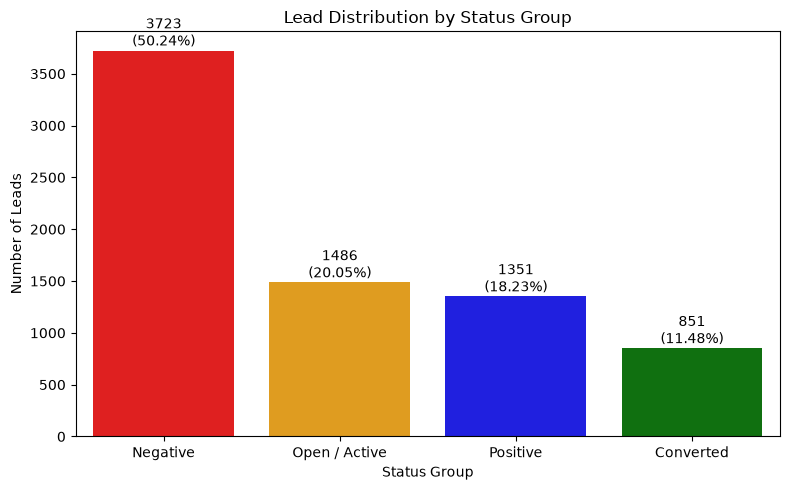

In [29]:
status_counts = df['Status_Group'].value_counts()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    palette=['red', 'orange', 'blue', 'green'],
    hue=status_counts.index,
    legend=False
)

plt.title('Lead Distribution by Status Group')
plt.xlabel('Status Group')
plt.ylabel('Number of Leads')

for i, value in enumerate(status_counts.values):
    percentage = value / len(df) * 100
    ax.text(
        i,
        value + 50,
        f'{value}\n({percentage:.2f}%)',
        ha='center'
    )

plt.tight_layout()
plt.show()

### Source Grouping

In [30]:
print(df['Source'].value_counts())

Source
Call                             2556
Live Chat-Direct                 1834
Website                          1592
Live Chat-Google Organic          274
Live Chat -PPC                    249
Live Chat-Blog                    237
Customer Referral                 179
US Website                        137
Just Dial                          56
Existing Client                    51
Live Chat-CPC                      50
Personal Contact                   50
By Recommendation                  32
CRM form                           23
Existing Customer                  22
Live Chat-Google Ads               21
Campaign                           19
E-mail Campaign                    12
Live Chat-Adwords Remarketing       7
Live Chat-Quora                     2
Other                               2
SMS Campaign                        2
Live Chat-Youtube                   2
E-Mail Message                      1
Live Chat-Justdial                  1
Name: count, dtype: int64


In [31]:
# 1.Create Source_Group
source_group_map = {

    # Direct
    'Call': 'Direct',
    'Live Chat-Direct': 'Direct',
    'Just Dial': 'Direct',
    'CRM form': 'Direct',
    'Other': 'Direct',

    # Website / Organic
    'Website': 'Website / Organic',
    'US Website': 'Website / Organic',
    'Live Chat-Google Organic': 'Website / Organic',
    'Live Chat-Blog': 'Website / Organic',

    # Paid / Digital
    'Live Chat -PPC': 'Paid / Digital',
    'Live Chat-CPC': 'Paid / Digital',
    'Live Chat-Google Ads': 'Paid / Digital',
    'Live Chat-Adwords Remarketing': 'Paid / Digital',
    'Campaign': 'Paid / Digital',
    'E-mail Campaign': 'Paid / Digital',
    'E-Mail Message': 'Paid / Digital',
    'SMS Campaign': 'Paid / Digital',
    'Live Chat-Quora': 'Paid / Digital',
    'Live Chat-Youtube': 'Paid / Digital',

    # Referral / Existing
    'Customer Referral': 'Referral / Existing',
    'Existing Client': 'Referral / Existing',
    'Existing Customer': 'Referral / Existing',
    'Personal Contact': 'Referral / Existing',
    'By Recommendation': 'Referral / Existing',
    'Live Chat-Justdial': 'Referral / Existing'
}

df['Source_Group'] = df['Source'].map(source_group_map)

In [32]:
# 2 Important validation
print(df[['Source', 'Source_Group']].drop_duplicates().sort_values('Source'))

                             Source         Source_Group
33                By Recommendation  Referral / Existing
4977                       CRM form               Direct
13                             Call               Direct
2944                       Campaign       Paid / Digital
56                Customer Referral  Referral / Existing
178                  E-Mail Message       Paid / Digital
4356                E-mail Campaign       Paid / Digital
238                 Existing Client  Referral / Existing
1193              Existing Customer  Referral / Existing
2449                      Just Dial               Direct
83                   Live Chat -PPC       Paid / Digital
143   Live Chat-Adwords Remarketing       Paid / Digital
69                   Live Chat-Blog    Website / Organic
358                   Live Chat-CPC       Paid / Digital
27                 Live Chat-Direct               Direct
106            Live Chat-Google Ads       Paid / Digital
18         Live Chat-Google Org

In [33]:
# 3.Varify
print("\nSource Group Count:")
print(df['Source_Group'].value_counts())

print("\nMissing Source Groups:")
print(df['Source_Group'].isna().sum())


Source Group Count:
Source_Group
Direct                 4471
Website / Organic      2240
Paid / Digital          365
Referral / Existing     335
Name: count, dtype: int64

Missing Source Groups:
0


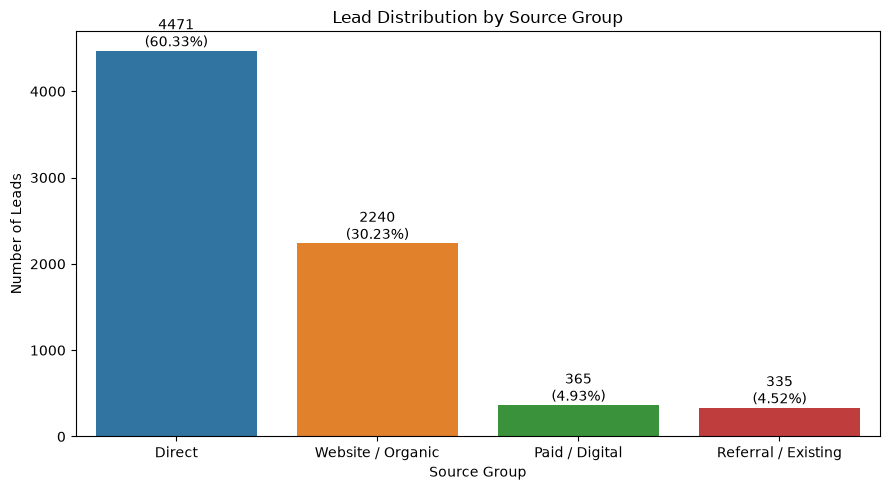

In [34]:
# 4.Source_Group Visualization
source_group_counts = df['Source_Group'].value_counts()
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=source_group_counts.index,
    y=source_group_counts.values,
    hue=source_group_counts.index,
    legend=False
)

plt.title('Lead Distribution by Source Group')
plt.xlabel('Source Group')
plt.ylabel('Number of Leads')

for i, value in enumerate(source_group_counts.values):
    percentage = value / len(df) * 100
    ax.text(
        i,
        value + 50,
        f'{value}\n({percentage:.2f}%)',
        ha='center'
    )

plt.tight_layout()
plt.show()

### Location_Group

In [35]:
# 1.Exact mapping
location_group_map = {

    # Major Indian Cities
    'Bangalore': 'Major Indian Cities',
    'Chennai': 'Major Indian Cities',
    'Hyderabad': 'Major Indian Cities',
    'Delhi': 'Major Indian Cities',
    'Mumbai': 'Major Indian Cities',
    'Pune': 'Major Indian Cities',

    # Other Indian Locations
    'Trivandrum': 'Other Indian Locations',
    'Kolkata': 'Other Indian Locations',
    'Howrah': 'Other Indian Locations',
    'Other Locations': 'Other Indian Locations',

    # International
    'UAE': 'International',
    'USA': 'International',
    'UK': 'International',
    'AUSTRALIA': 'International',
    'Singapore': 'International',
    'Malaysia': 'International',
    'EUROPE': 'International',

    # Unknown
    'Unknown': 'Unknown'
}

df['Location_Group'] = df['Location'].map(location_group_map)

In [36]:
# 2.Validation
print("Location Group Count:")
print(df['Location_Group'].value_counts())

print("\nMissing Location Groups:")
print(df['Location_Group'].isna().sum())

Location Group Count:
Location_Group
Major Indian Cities       4535
Other Indian Locations    2606
International              214
Unknown                     56
Name: count, dtype: int64

Missing Location Groups:
0


In [37]:
# 3.verify
print(
    df[['Location', 'Location_Group']]
    .drop_duplicates()
    .sort_values('Location')
)

             Location          Location_Group
270         AUSTRALIA           International
18          Bangalore     Major Indian Cities
28            Chennai     Major Indian Cities
39              Delhi     Major Indian Cities
881            EUROPE           International
5773           Howrah  Other Indian Locations
25          Hyderabad     Major Indian Cities
112           Kolkata  Other Indian Locations
2645         Malaysia           International
52             Mumbai     Major Indian Cities
19    Other Locations  Other Indian Locations
159              Pune     Major Indian Cities
140         Singapore           International
24         Trivandrum  Other Indian Locations
23                UAE           International
29                 UK           International
38                USA           International
0             Unknown                 Unknown


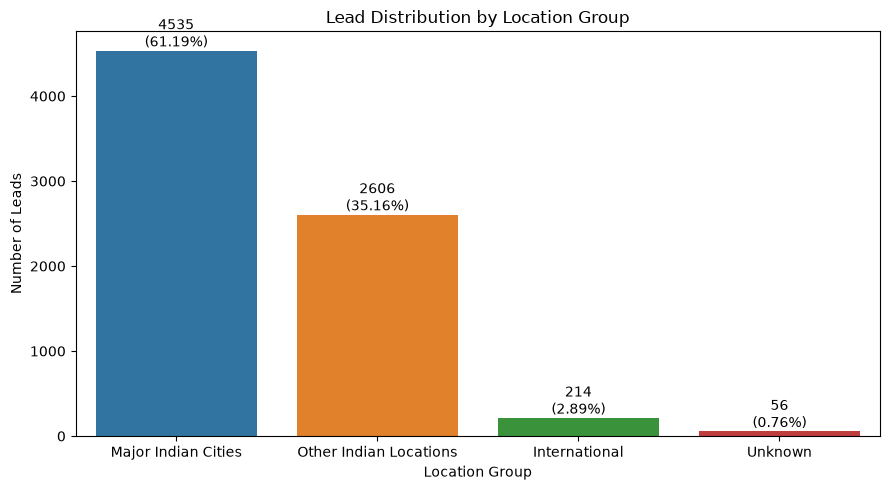

In [38]:
# 4.Location_Group Visualization
import seaborn as sns
import matplotlib.pyplot as plt

location_group_counts = df['Location_Group'].value_counts()

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=location_group_counts.index,
    y=location_group_counts.values,
    hue=location_group_counts.index,
    legend=False
)

plt.title('Lead Distribution by Location Group')
plt.xlabel('Location Group')
plt.ylabel('Number of Leads')

for i, value in enumerate(location_group_counts.values):
    percentage = value / len(df) * 100
    ax.text(
        i,
        value + 50,
        f'{value}\n({percentage:.2f}%)',
        ha='center'
    )

plt.tight_layout()
plt.show()

### Sales Agent Analysis

In [39]:
# 1.Agent-wise Lead Count
agent_counts = df['Sales_Agent'].value_counts()
print(agent_counts)

# 2.Agent-wise Percentage
agent_analysis = pd.DataFrame({
    'Lead_Count': df['Sales_Agent'].value_counts(),
    'Percentage': (
        df['Sales_Agent'].value_counts(normalize=True) * 100
    ).round(2)
})

print(agent_analysis)

Sales_Agent
Sales-Agent-4     1518
Sales-Agent-11    1418
Sales-Agent-5     1189
Sales-Agent-9      879
Sales-Agent-3      780
Sales-Agent-7      736
Sales-Agent-2      389
Sales-Agent-12     269
Sales-Agent-6      114
Sales-Agent-8       68
Sales-Agent-10      47
Sales-Agent-1        4
Name: count, dtype: int64
                Lead_Count  Percentage
Sales_Agent                           
Sales-Agent-4         1518       20.48
Sales-Agent-11        1418       19.13
Sales-Agent-5         1189       16.04
Sales-Agent-9          879       11.86
Sales-Agent-3          780       10.52
Sales-Agent-7          736        9.93
Sales-Agent-2          389        5.25
Sales-Agent-12         269        3.63
Sales-Agent-6          114        1.54
Sales-Agent-8           68        0.92
Sales-Agent-10          47        0.63
Sales-Agent-1            4        0.05


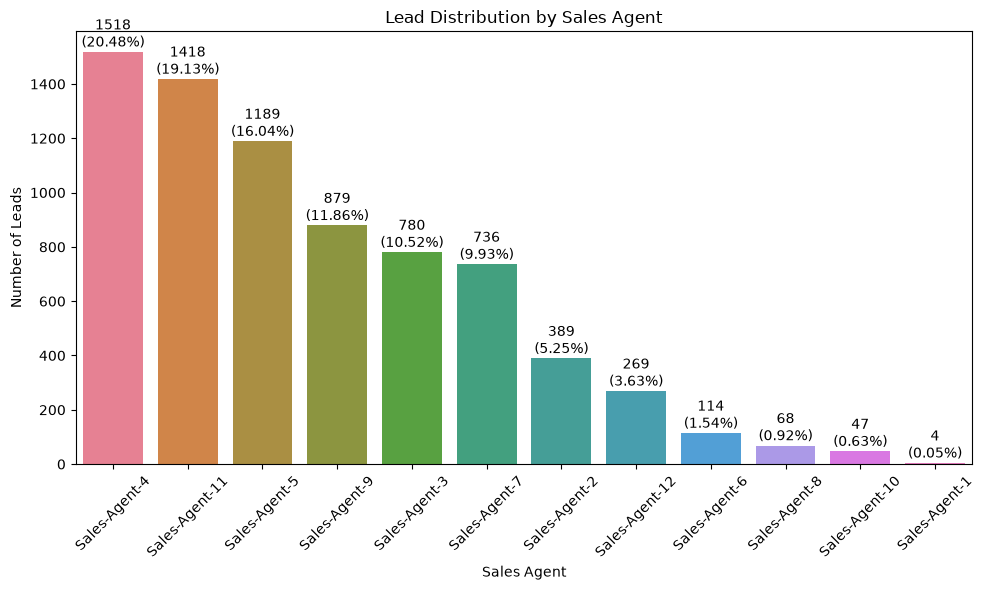

In [40]:
# 3.Visualization
agent_counts = df['Sales_Agent'].value_counts()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=agent_counts.index,
    y=agent_counts.values,
    hue=agent_counts.index,
    legend=False
)

plt.title('Lead Distribution by Sales Agent')
plt.xlabel('Sales Agent')
plt.ylabel('Number of Leads')
plt.xticks(rotation=45)

for i, value in enumerate(agent_counts.values):
    percentage = value / len(df) * 100
    ax.text(
        i,
        value + 20,
        f'{value}\n({percentage:.2f}%)',
        ha='center'
    )

plt.tight_layout()
plt.show()

## Delivery Mode Analysis

In [41]:
# 1.Delivery Mode Count + Percentage
delivery_counts = df['Delivery_Mode'].value_counts()

delivery_analysis = pd.DataFrame({
    'Lead_Count': delivery_counts,
    'Percentage': (
        df['Delivery_Mode']
        .value_counts(normalize=True) * 100
    ).round(2)
})

print(delivery_analysis)

               Lead_Count  Percentage
Delivery_Mode                        
Mode-5               2964       39.99
Mode-1               2627       35.45
Mode-3               1688       22.78
Mode-4                121        1.63
Mode-2                 11        0.15


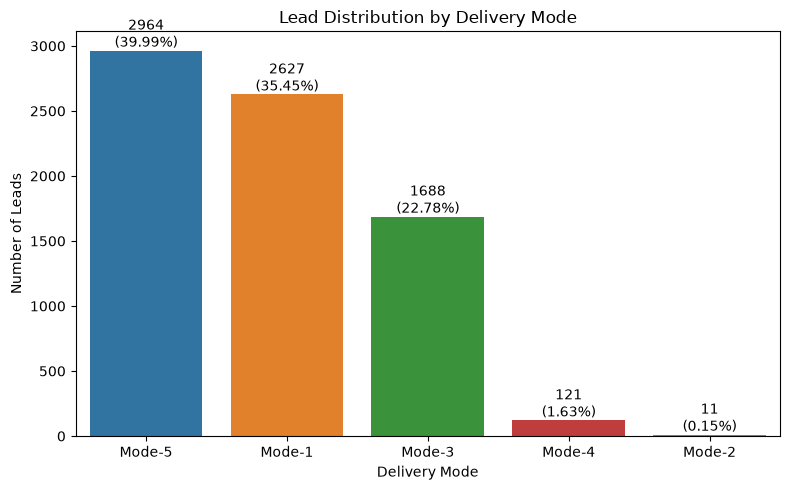

In [42]:
# 2.Visualization
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=delivery_counts.index,
    y=delivery_counts.values,
    hue=delivery_counts.index,
    legend=False
)

plt.title('Lead Distribution by Delivery Mode')
plt.xlabel('Delivery Mode')
plt.ylabel('Number of Leads')

for i, value in enumerate(delivery_counts.values):
    percentage = value / len(df) * 100
    ax.text(
        i,
        value + 30,
        f'{value}\n({percentage:.2f}%)',
        ha='center'
    )

plt.tight_layout()
plt.show()

## Date / Time Analysis

In [43]:
# 1 Create Date Features
df['Year'] = df['Created'].dt.year
df['Month'] = df['Created'].dt.month
df['Month_Name'] = df['Created'].dt.month_name()
df['Day'] = df['Created'].dt.day
df['Day_of_Week'] = df['Created'].dt.day_name()
df['Hour'] = df['Created'].dt.hour

In [44]:
# 2 Check the new columns
print(df[
    [
        'Created',
        'Year',
        'Month',
        'Month_Name',
        'Day',
        'Day_of_Week',
        'Hour'
    ]
].head(10))

              Created  Year  Month Month_Name  Day Day_of_Week  Hour
0 2018-11-14 10:05:00  2018     11   November   14   Wednesday    10
1 2018-11-14 09:22:00  2018     11   November   14   Wednesday     9
2 2018-11-14 09:21:00  2018     11   November   14   Wednesday     9
3 2018-11-14 08:46:00  2018     11   November   14   Wednesday     8
4 2018-11-14 07:34:00  2018     11   November   14   Wednesday     7
5 2018-11-14 07:33:00  2018     11   November   14   Wednesday     7
6 2018-11-14 05:58:00  2018     11   November   14   Wednesday     5
7 2018-11-14 05:49:00  2018     11   November   14   Wednesday     5
8 2018-11-14 05:40:00  2018     11   November   14   Wednesday     5
9 2018-11-14 05:06:00  2018     11   November   14   Wednesday     5


In [45]:
# 3 Check data types
print(df[
    [
        'Year',
        'Month',
        'Month_Name',
        'Day',
        'Day_of_Week',
        'Hour'
    ]
].dtypes)

Year           int32
Month          int32
Month_Name       str
Day            int32
Day_of_Week      str
Hour           int32
dtype: object


### 1 Month-wise Lead Analysis

In [46]:
# 1.Month Count + Percentage
monthly_leads = (
    df.groupby(['Month', 'Month_Name'])
      .size()
      .reset_index(name='Lead_Count')
      .sort_values('Month')
)

monthly_leads['Percentage'] = (
    monthly_leads['Lead_Count'] / len(df) * 100
).round(2)

print(monthly_leads)

   Month Month_Name  Lead_Count  Percentage
0      4      April         115        1.55
1      5        May        1260       17.00
2      6       June        1281       17.29
3      7       July        1156       15.60
4      8     August        1116       15.06
5      9  September        1102       14.87
6     10    October        1000       13.49
7     11   November         381        5.14


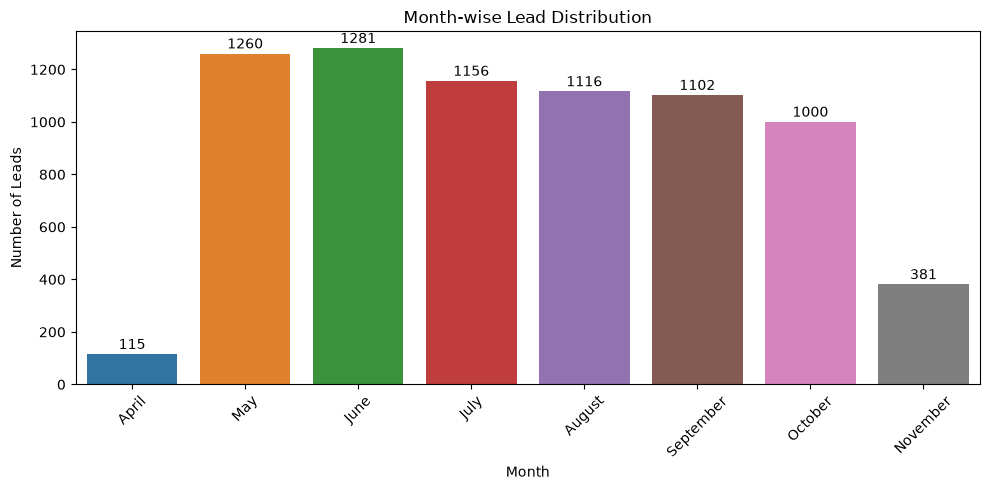

In [47]:
# 2.Visualization
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=monthly_leads,
    x='Month_Name',
    y='Lead_Count',
    hue='Month_Name',
    order=monthly_leads['Month_Name'],
    legend=False
)

plt.title('Month-wise Lead Distribution')
plt.xlabel('Month')
plt.ylabel('Number of Leads')
plt.xticks(rotation=45)

for i, value in enumerate(monthly_leads['Lead_Count']):
    ax.text(
        i,
        value + 20,
        str(value),
        ha='center'
    )

plt.tight_layout()
plt.show()

### Day-of-Week Analysis

In [48]:
# 1 Day-wise Lead Count
daywise_leads = (
    df.groupby(['Day_of_Week'])
      .size()
      .reset_index(name='Lead_Count')
)

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

daywise_leads['Day_of_Week'] = pd.Categorical(
    daywise_leads['Day_of_Week'],
    categories=day_order,
    ordered=True
)

daywise_leads = daywise_leads.sort_values('Day_of_Week')

daywise_leads['Percentage'] = (
    daywise_leads['Lead_Count'] / len(df) * 100
).round(2)

print(daywise_leads)

  Day_of_Week  Lead_Count  Percentage
1      Monday        1511       20.39
5     Tuesday        1316       17.76
6   Wednesday        1270       17.14
4    Thursday        1095       14.78
0      Friday        1065       14.37
2    Saturday         756       10.20
3      Sunday         398        5.37


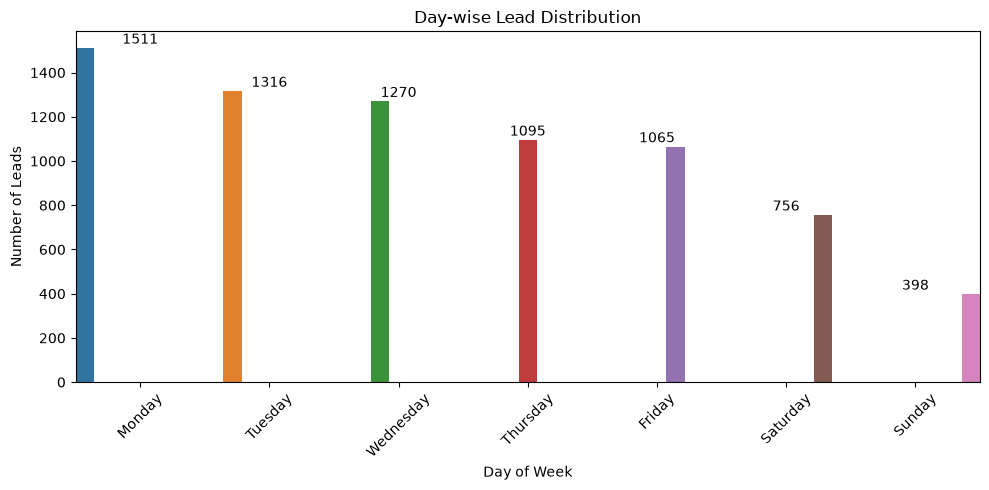

In [49]:
# 2 Visualization
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=daywise_leads,
    x='Day_of_Week',
    y='Lead_Count',
    hue='Day_of_Week',
    legend=False,
    width=1
)

plt.title('Day-wise Lead Distribution')
plt.xlabel('Day of Week')
plt.ylabel('Number of Leads')
plt.xticks(rotation=45)

for i, value in enumerate(daywise_leads['Lead_Count']):
    ax.text(
        i,
        value + 20,
        str(value),
        ha='center'
    )

plt.tight_layout()
plt.show()

### Hour-wise Lead Analysis

In [50]:
# 1.Hour-wise Lead Count
hourwise_leads = (
    df.groupby('Hour')
      .size()
      .reset_index(name='Lead_Count')
      .sort_values('Hour')
)

hourwise_leads['Percentage'] = (
    hourwise_leads['Lead_Count'] / len(df) * 100
).round(2)

print(hourwise_leads)

    Hour  Lead_Count  Percentage
0      0          79        1.07
1      1          46        0.62
2      2          29        0.39
3      3          31        0.42
4      4          29        0.39
5      5          32        0.43
6      6          28        0.38
7      7          46        0.62
8      8          73        0.99
9      9         332        4.48
10    10         913       12.32
11    11        1011       13.64
12    12         866       11.69
13    13         551        7.43
14    14         520        7.02
15    15         600        8.10
16    16         564        7.61
17    17         499        6.73
18    18         446        6.02
19    19         234        3.16
20    20         183        2.47
21    21         116        1.57
22    22          94        1.27
23    23          89        1.20


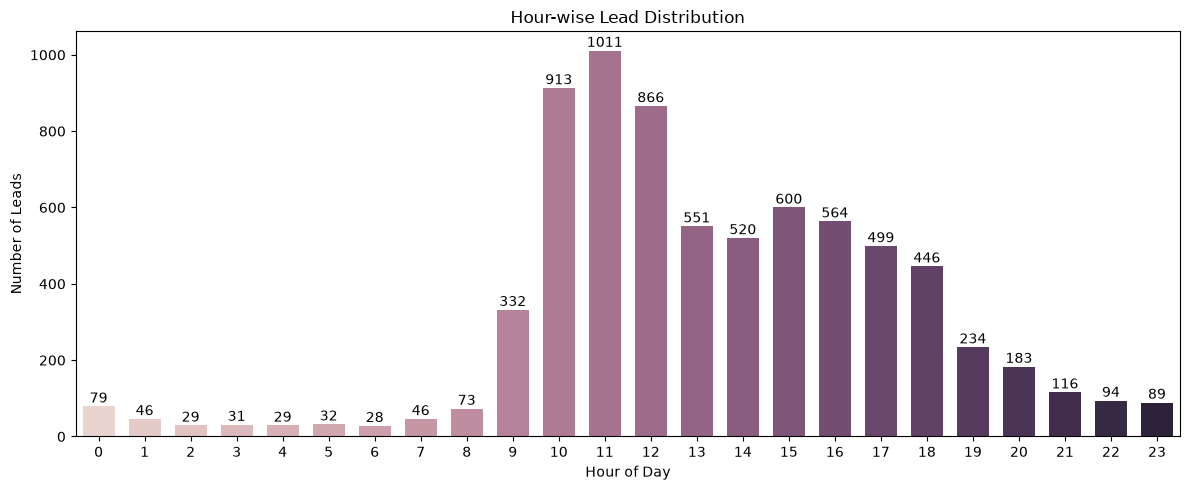

In [51]:
# 2.Visualization
plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=hourwise_leads,
    x='Hour',
    y='Lead_Count',
    hue='Hour',
    legend=False,
    width=0.7
)

plt.title('Hour-wise Lead Distribution')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Leads')

for i, value in enumerate(hourwise_leads['Lead_Count']):
    ax.text(
        i,
        value + 10,
        str(value),
        ha='center'
    )

plt.tight_layout()
plt.show()

## Cross Analysis

### Status Group vs Source Group

In [52]:
# 1. Crosstab
source_status = pd.crosstab(
    df['Source_Group'],
    df['Status_Group']
)
print(source_status)

Status_Group         Converted  Negative  Open / Active  Positive
Source_Group                                                     
Direct                     428      2341            863       839
Paid / Digital              24       184             97        60
Referral / Existing        202        33             24        76
Website / Organic          197      1165            502       376


In [53]:
# 2.Percentage Distribution
source_status_pct = pd.crosstab(
    df['Source_Group'],
    df['Status_Group'],
    normalize='index'
).mul(100).round(2)

print(source_status_pct)

Status_Group         Converted  Negative  Open / Active  Positive
Source_Group                                                     
Direct                    9.57     52.36          19.30     18.77
Paid / Digital            6.58     50.41          26.58     16.44
Referral / Existing      60.30      9.85           7.16     22.69
Website / Organic         8.79     52.01          22.41     16.79


<Figure size 1200x600 with 0 Axes>

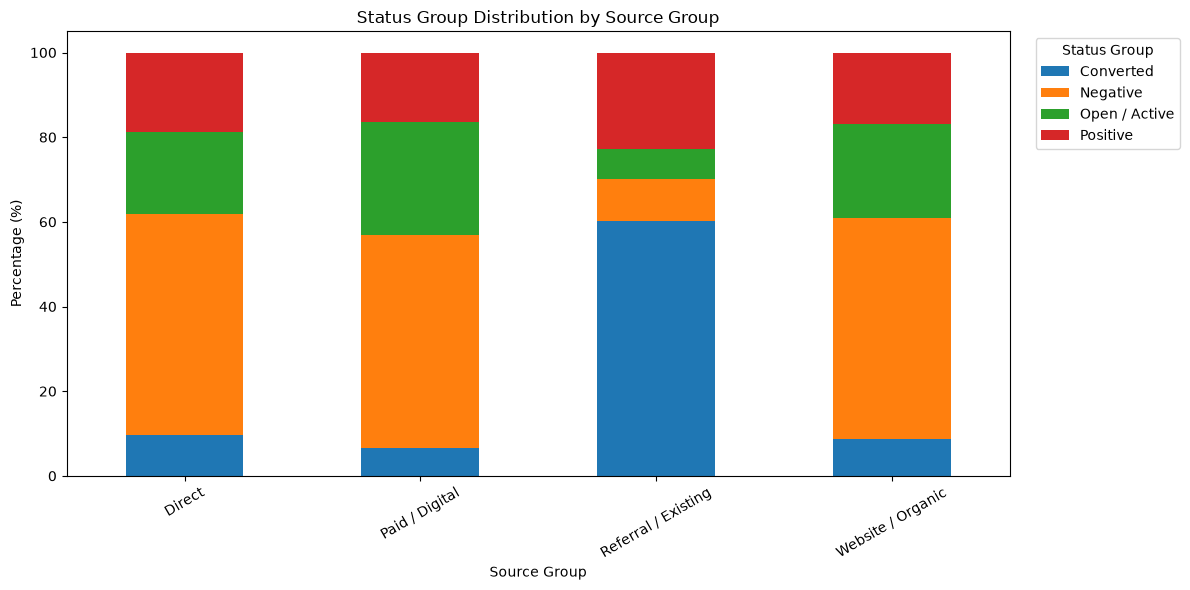

In [54]:
# 3.Visualization
plt.figure(figsize=(12, 6))

source_status_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Status Group Distribution by Source Group')
plt.xlabel('Source Group')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30)
plt.legend(title='Status Group', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Status Group vs Location Group

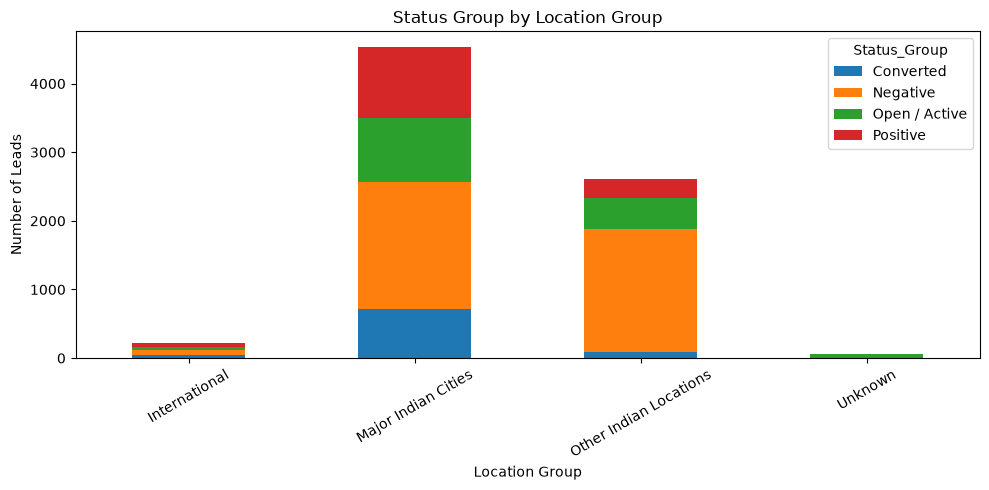

In [55]:
location_status = pd.crosstab(
    df['Location_Group'],
    df['Status_Group']
)

location_status.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)

plt.title('Status Group by Location Group')
plt.xlabel('Location Group')
plt.ylabel('Number of Leads')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Status Group vs Sales Agent

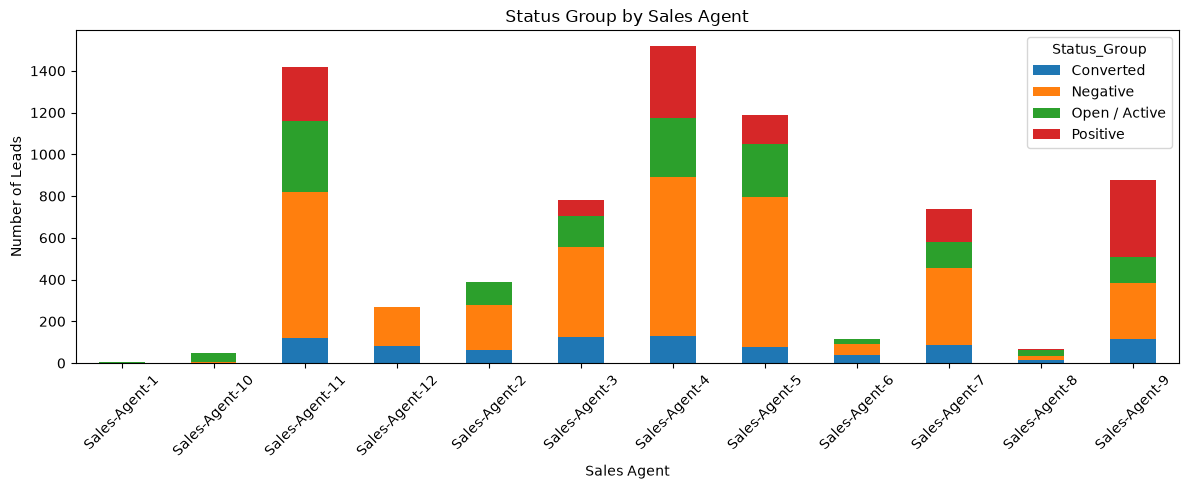

In [56]:
agent_status = pd.crosstab(
    df['Sales_Agent'],
    df['Status_Group']
)

agent_status.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 5)
)

plt.title('Status Group by Sales Agent')
plt.xlabel('Sales Agent')
plt.ylabel('Number of Leads')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Status Group vs Delivery Mode

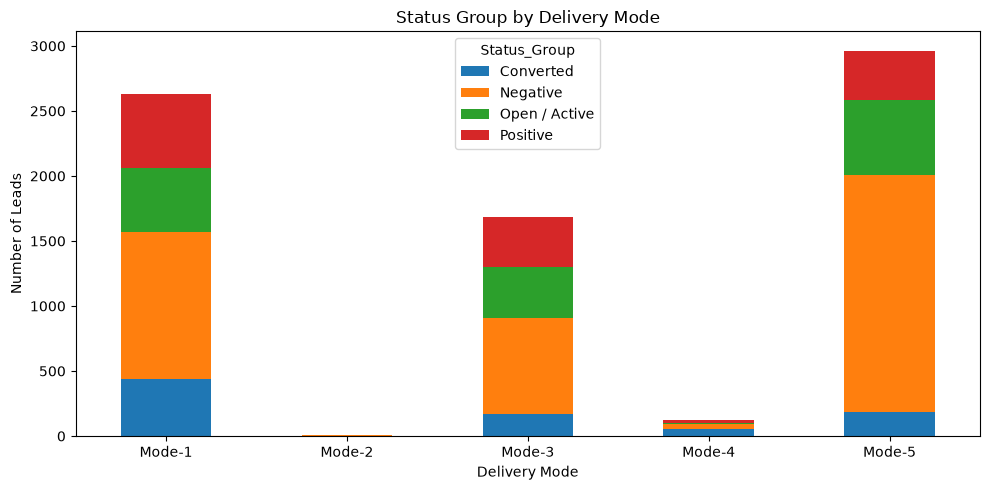

In [57]:
delivery_status = pd.crosstab(
    df['Delivery_Mode'],
    df['Status_Group']
)

delivery_status.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)

plt.title('Status Group by Delivery Mode')
plt.xlabel('Delivery Mode')
plt.ylabel('Number of Leads')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Month-wise Status Group Trend

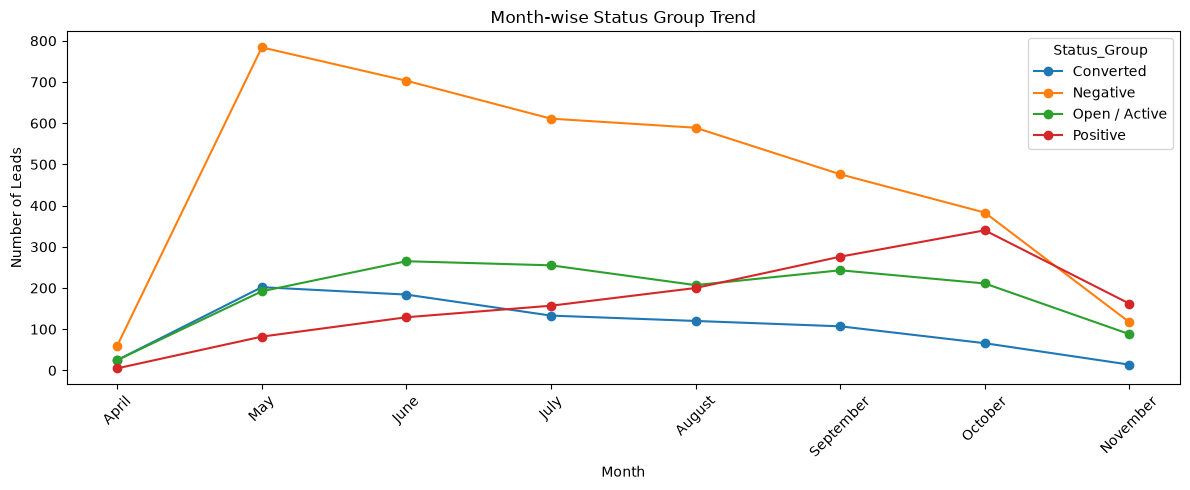

In [58]:
monthly_status = pd.crosstab(
    df['Month_Name'],
    df['Status_Group']
)

month_order = [
    'April', 'May', 'June', 'July',
    'August', 'September', 'October', 'November'
]

monthly_status = monthly_status.reindex(month_order)

monthly_status.plot(
    kind='line',
    marker='o',
    figsize=(12, 5)
)

plt.title('Month-wise Status Group Trend')
plt.xlabel('Month')
plt.ylabel('Number of Leads')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# IQR / Outlier Analysis

In [59]:
daily_leads = (
    df.groupby(df['Created'].dt.date)
      .size()
      .reset_index(name='Lead_Count')
)

Q1 = daily_leads['Lead_Count'].quantile(0.25)
Q3 = daily_leads['Lead_Count'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = daily_leads[
    (daily_leads['Lead_Count'] < lower) |
    (daily_leads['Lead_Count'] > upper)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)
print("Outlier Days:", len(outliers))

Q1: 27.0
Q3: 48.0
IQR: 21.0
Lower Bound: -4.5
Upper Bound: 79.5
Outlier Days: 1


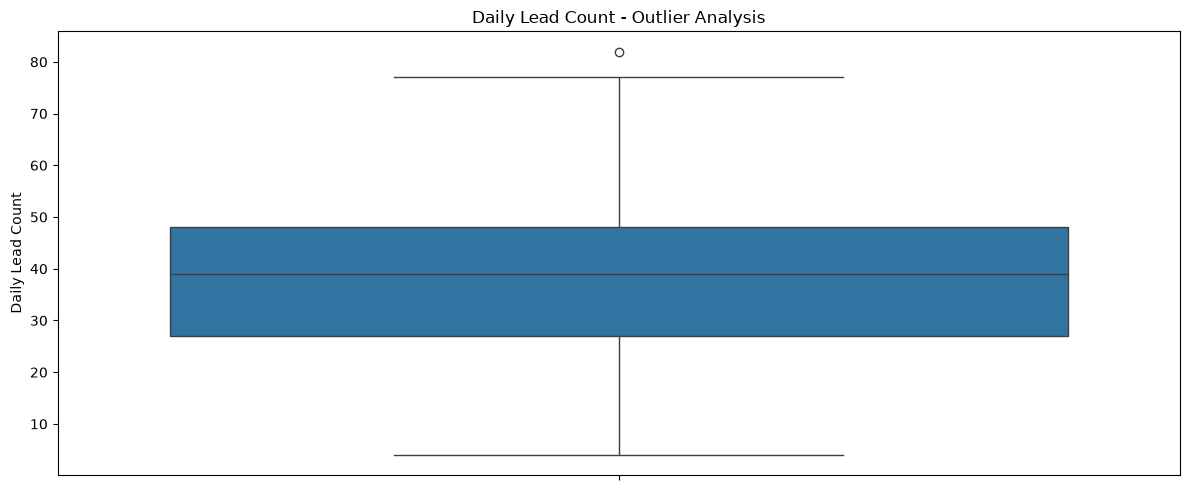

In [60]:
# Outlier chart
plt.figure(figsize=(12, 5))

sns.boxplot(y=daily_leads['Lead_Count'])

plt.title('Daily Lead Count - Outlier Analysis')
plt.ylabel('Daily Lead Count')

plt.tight_layout()
plt.show()

# Feature Engineering

In [61]:
# 1 Converted Flag
df['Converted_Flag'] = (
    df['Status_Group'] == 'Converted'
).astype(int)

In [62]:
# 2 Weekend Flag
df['Weekend_Flag'] = (
    df['Day_of_Week'].isin(['Saturday', 'Sunday'])
).astype(int)

In [63]:
# 3 Check
print(df[['Status_Group', 'Converted_Flag',
          'Day_of_Week', 'Weekend_Flag']].head())

print(df['Converted_Flag'].value_counts())
print(df['Weekend_Flag'].value_counts())

    Status_Group  Converted_Flag Day_of_Week  Weekend_Flag
0  Open / Active               0   Wednesday             0
1  Open / Active               0   Wednesday             0
2  Open / Active               0   Wednesday             0
3  Open / Active               0   Wednesday             0
4  Open / Active               0   Wednesday             0
Converted_Flag
0    6560
1     851
Name: count, dtype: int64
Weekend_Flag
0    6257
1    1154
Name: count, dtype: int64


### 2 Month-Year Feature

In [64]:
df['Month_Year'] = df['Created'].dt.to_period('M').astype(str)
print(df[['Created', 'Month_Year']].head())

              Created Month_Year
0 2018-11-14 10:05:00    2018-11
1 2018-11-14 09:22:00    2018-11
2 2018-11-14 09:21:00    2018-11
3 2018-11-14 08:46:00    2018-11
4 2018-11-14 07:34:00    2018-11


### 3 Final Feature Check

In [65]:
print(df.columns.tolist())
print(df.shape)
print(df.isna().sum())

['Created', 'Product_ID', 'Source', 'Sales_Agent', 'Location', 'Delivery_Mode', 'Status', 'Status_Clean', 'Status_Group', 'Source_Group', 'Location_Group', 'Year', 'Month', 'Month_Name', 'Day', 'Day_of_Week', 'Hour', 'Converted_Flag', 'Weekend_Flag', 'Month_Year']
(7411, 20)
Created           0
Product_ID        0
Source            0
Sales_Agent       0
Location          0
Delivery_Mode     0
Status            0
Status_Clean      0
Status_Group      0
Source_Group      0
Location_Group    0
Year              0
Month             0
Month_Name        0
Day               0
Day_of_Week       0
Hour              0
Converted_Flag    0
Weekend_Flag      0
Month_Year        0
dtype: int64


## Final Dataset Validation

In [66]:
print("Final Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())
print("Total Missing Values:", df.isna().sum().sum())
print("\nColumns:")
print(df.columns.tolist())

Final Shape: (7411, 20)
Duplicate Rows: 0
Total Missing Values: 0

Columns:
['Created', 'Product_ID', 'Source', 'Sales_Agent', 'Location', 'Delivery_Mode', 'Status', 'Status_Clean', 'Status_Group', 'Source_Group', 'Location_Group', 'Year', 'Month', 'Month_Name', 'Day', 'Day_of_Week', 'Hour', 'Converted_Flag', 'Weekend_Flag', 'Month_Year']


# 5. Machine Learning — Target Creation

## Converted vs Not Converted prediction

In [67]:
df['Target'] = (
    df['Status_Group'] == 'Converted'
).astype(int)
print(df['Target'].value_counts())

Target
0    6560
1     851
Name: count, dtype: int64


In [68]:
# 1.ML Features Select
features = [
    'Product_ID',
    'Source_Group',
    'Sales_Agent',
    'Location_Group',
    'Delivery_Mode',
    'Year',
    'Month',
    'Day_of_Week',
    'Hour',
    'Weekend_Flag'
]

X = df[features]
y = df['Target']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (7411, 10)
y Shape: (7411,)


In [69]:
# 2 Train / Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5928, 10)
X_test : (1483, 10)
y_train: (5928,)
y_test : (1483,)


In [70]:
# 3 Categorical Encoding
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    'Product_ID',
    'Source_Group',
    'Sales_Agent',
    'Location_Group',
    'Delivery_Mode',
    'Day_of_Week'
]

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

print("Encoded X_train Shape:", X_train_encoded.shape)
print("Encoded X_test Shape:", X_test_encoded.shape)

Encoded X_train Shape: (5928, 61)
Encoded X_test Shape: (1483, 61)


In [71]:
# 4 Numeric Features + Final ML Dataset
numeric_cols = [
    'Year',
    'Month',
    'Hour',
    'Weekend_Flag'
]

X_train_num = X_train[numeric_cols].values
X_test_num = X_test[numeric_cols].values

In [72]:
# categorical + numeric combine:
import numpy as np

X_train_final = np.hstack([
    X_train_encoded,
    X_train_num
])

X_test_final = np.hstack([
    X_test_encoded,
    X_test_num
])

print("Final X_train:", X_train_final.shape)
print("Final X_test :", X_test_final.shape)

Final X_train: (5928, 65)
Final X_test : (1483, 65)


In [73]:
# 5 Model Training — SVC //SVC (Support Vector Classifier)
from sklearn.svm import SVC

sv = SVC()

sv.fit(X_train_final, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [74]:
# 6 Prediction + Evaluation
y_pred = sv.predict(X_test_final)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [75]:
# Accuracy + Classification Report
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8853674983142279

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1313
           1       0.00      0.00      0.00       170

    accuracy                           0.89      1483
   macro avg       0.44      0.50      0.47      1483
weighted avg       0.78      0.89      0.83      1483



In [76]:
# SVC improve
sv_balanced = SVC(class_weight='balanced')

sv_balanced.fit(X_train_final, y_train)

y_pred_balanced = sv_balanced.predict(X_test_final)
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))

print(
    classification_report(
        y_test,
        y_pred_balanced,
        zero_division=0
    )
)

Accuracy: 0.11463250168577209
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1313
           1       0.11      1.00      0.21       170

    accuracy                           0.11      1483
   macro avg       0.06      0.50      0.10      1483
weighted avg       0.01      0.11      0.02      1483



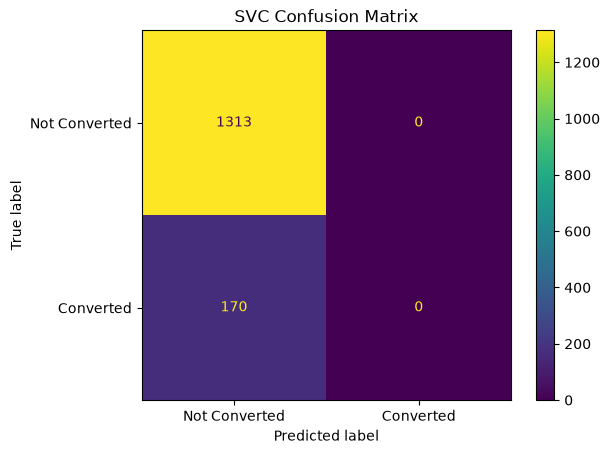

In [77]:
# 7 Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Converted', 'Converted']
)

disp.plot()

plt.title('SVC Confusion Matrix')
plt.show()

## Logistic Regression

### Insight
Logistic Regression is evaluated with class balancing because Converted leads are a minority class in this dataset.


In [78]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

lr.fit(X_train_final, y_train)

C:\Users\nagap\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [79]:
# Prediction + Evaluation
y_pred_lr = lr.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

Accuracy: 0.7006068779501011

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.70      0.80      1313
           1       0.24      0.74      0.36       170

    accuracy                           0.70      1483
   macro avg       0.60      0.72      0.58      1483
weighted avg       0.87      0.70      0.75      1483



In [80]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train_final, y_train)

y_pred_rf = rf.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Accuracy: 0.8556979096426163

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.92      1313
           1       0.36      0.32      0.34       170

    accuracy                           0.86      1483
   macro avg       0.64      0.62      0.63      1483
weighted avg       0.85      0.86      0.85      1483



## Logistic Regression — Confusion Matrix

### Insight
Logistic Regression is evaluated with class balancing because Converted leads are a minority class in this dataset.


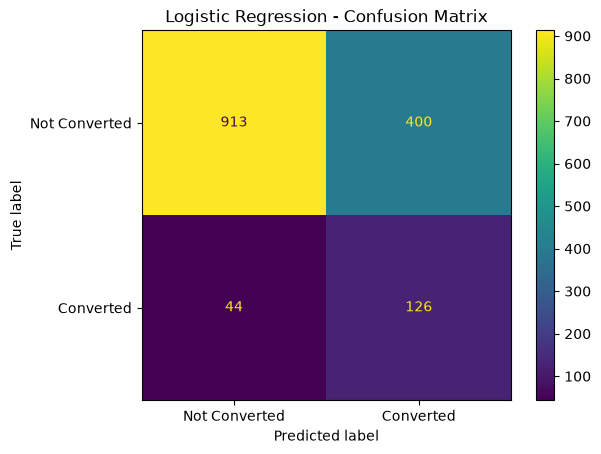

In [81]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['Not Converted', 'Converted']
)

disp.plot()

plt.title('Logistic Regression - Confusion Matrix')
plt.show()

## Model Comparison

### Insight
The three models show different metric patterns. SVC reaches about **0.89 accuracy but 0.00 Converted recall**, Logistic Regression reaches about **0.70 accuracy and 0.74 Converted recall**, and Random Forest reaches about **0.86 accuracy and 0.32 Converted recall**. This demonstrates why accuracy alone is not sufficient for an imbalanced conversion problem.


In [82]:
model_comparison = pd.DataFrame({
    'Model': [
        'SVC',
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Converted_Recall': [
        classification_report(y_test, y_pred, output_dict=True, zero_division=0)['1']['recall'],
        classification_report(y_test, y_pred_lr, output_dict=True, zero_division=0)['1']['recall'],
        classification_report(y_test, y_pred_rf, output_dict=True, zero_division=0)['1']['recall']
    ],
    'Converted_F1': [
        classification_report(y_test, y_pred, output_dict=True, zero_division=0)['1']['f1-score'],
        classification_report(y_test, y_pred_lr, output_dict=True, zero_division=0)['1']['f1-score'],
        classification_report(y_test, y_pred_rf, output_dict=True, zero_division=0)['1']['f1-score']
    ]
})

print(model_comparison.round(2))

                 Model  Accuracy  Converted_Recall  Converted_F1
0                  SVC      0.89              0.00          0.00
1  Logistic Regression      0.70              0.74          0.36
2        Random Forest      0.86              0.32          0.34


In [83]:
# ML Feature Importance
importance = rf.feature_importances_

print("Number of Features:", len(importance))

Number of Features: 65


### Feature Importance Chart

### Insight
The Random Forest feature-importance chart shows which encoded input features contributed most to that model's predictions. These are model-specific importance values and should not be interpreted as causal effects.


In [84]:
feature_names = encoder.get_feature_names_out(categorical_cols)

all_feature_names = list(feature_names) + numeric_cols

feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

print(feature_importance.head(15))

                                  Feature  Importance
63                                   Hour    0.175162
62                                  Month    0.114911
31       Source_Group_Referral / Existing    0.063872
7                           Product_ID_15    0.053604
46     Location_Group_Major Indian Cities    0.033556
47  Location_Group_Other Indian Locations    0.032316
11                          Product_ID_19    0.030757
55                     Day_of_Week_Monday    0.021988
29                    Source_Group_Direct    0.021879
59                    Day_of_Week_Tuesday    0.021683
60                  Day_of_Week_Wednesday    0.021501
39              Sales_Agent_Sales-Agent-4    0.021152
53                   Delivery_Mode_Mode-5    0.020850
58                   Day_of_Week_Thursday    0.019886
32         Source_Group_Website / Organic    0.019235


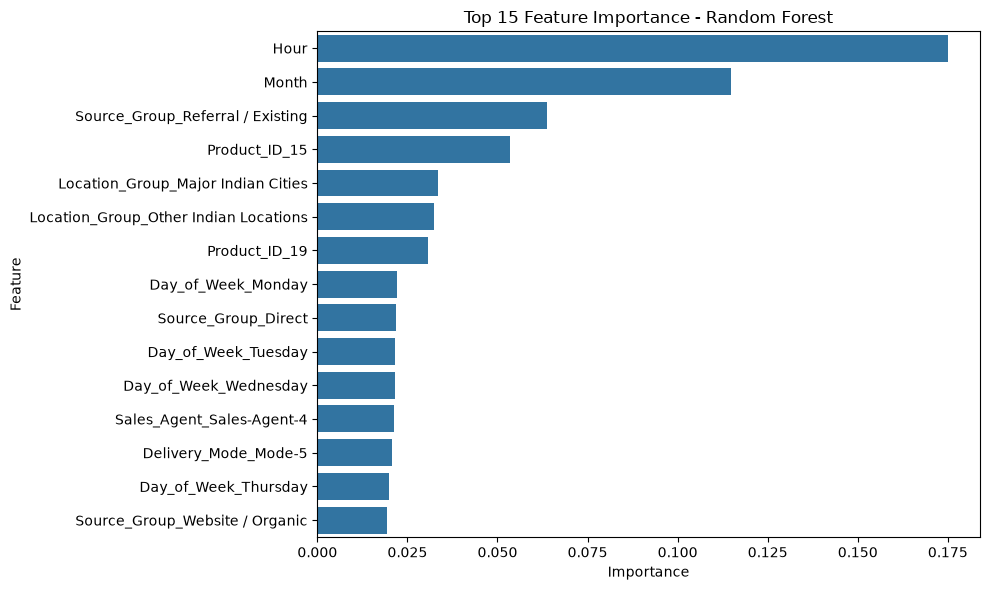

In [85]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

# ML Final Conclusion

In [86]:
# 1. Model comparison final check
print(model_comparison.round(2))

                 Model  Accuracy  Converted_Recall  Converted_F1
0                  SVC      0.89              0.00          0.00
1  Logistic Regression      0.70              0.74          0.36
2        Random Forest      0.86              0.32          0.34


In [87]:
# 2.2. Random Forest final classification report
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['Not Converted', 'Converted'],
    zero_division=0
))

               precision    recall  f1-score   support

Not Converted       0.91      0.92      0.92      1313
    Converted       0.36      0.32      0.34       170

     accuracy                           0.86      1483
    macro avg       0.64      0.62      0.63      1483
 weighted avg       0.85      0.86      0.85      1483



ML Conclusion:
- SVC achieved high accuracy but failed to identify Converted leads.
- Logistic Regression detected Converted leads better, with higher recall.
- Random Forest provided a balanced classification performance.
- Accuracy alone was not used to judge the models because the target classes are imbalanced.
- Precision, Recall, F1-score and Confusion Matrix were considered.

# Final Dataset Validation

In [88]:
print("Final Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())
print("Total Missing Values:", df.isna().sum().sum())

print("\nFinal Columns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Final Shape: (7411, 21)
Duplicate Rows: 0
Total Missing Values: 0

Final Columns:
['Created', 'Product_ID', 'Source', 'Sales_Agent', 'Location', 'Delivery_Mode', 'Status', 'Status_Clean', 'Status_Group', 'Source_Group', 'Location_Group', 'Year', 'Month', 'Month_Name', 'Day', 'Day_of_Week', 'Hour', 'Converted_Flag', 'Weekend_Flag', 'Month_Year', 'Target']

Data Types:
Created           datetime64[us]
Product_ID                string
Source                       str
Sales_Agent                  str
Location                     str
Delivery_Mode                str
Status                       str
Status_Clean                 str
Status_Group                 str
Source_Group                 str
Location_Group               str
Year                       int32
Month                      int32
Month_Name                   str
Day                        int32
Day_of_Week                  str
Hour                       int32
Converted_Flag             int64
Weekend_Flag               int64
Mon

In [89]:
# Final dataset preview
display(df.head())

,Created,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status,Status_Clean,Status_Group,Source_Group,...,Year,Month,Month_Name,Day,Day_of_Week,Hour,Converted_Flag,Weekend_Flag,Month_Year,Target
0,2018-11-14 10:05:00,Unknown,Website,Sales-Agent-11,Unknown,Mode-5,Open,Open,Open / Active,Website / Organic,...,2018,11,November,14,Wednesday,10,0,0,2018-11,0
1,2018-11-14 09:22:00,Unknown,Website,Sales-Agent-10,Unknown,Mode-5,Open,Open,Open / Active,Website / Organic,...,2018,11,November,14,Wednesday,9,0,0,2018-11,0
2,2018-11-14 09:21:00,Unknown,Website,Sales-Agent-10,Unknown,Mode-5,Open,Open,Open / Active,Website / Organic,...,2018,11,November,14,Wednesday,9,0,0,2018-11,0
3,2018-11-14 08:46:00,Unknown,Website,Sales-Agent-10,Unknown,Mode-5,Open,Open,Open / Active,Website / Organic,...,2018,11,November,14,Wednesday,8,0,0,2018-11,0
4,2018-11-14 07:34:00,Unknown,Website,Sales-Agent-10,Unknown,Mode-5,Open,Open,Open / Active,Website / Organic,...,2018,11,November,14,Wednesday,7,0,0,2018-11,0


In [90]:
# Important check
print(df['Status_Group'].value_counts())
print("\nTarget:")
print(df['Target'].value_counts())


Status_Group
Negative         3723
Open / Active    1486
Positive         1351
Converted         851
Name: count, dtype: int64

Target:
Target
0    6560
1     851
Name: count, dtype: int64


## Final Cleaned Dataset

In [91]:
final_file = 'sales_final_cleaned.csv'

df.to_csv(final_file, index=False)

print("File saved successfully:", final_file)
print("Shape:", df.shape)

File saved successfully: sales_final_cleaned.csv
Shape: (7411, 21)


In [92]:
df_check = pd.read_csv(final_file)

print("Reloaded Shape:", df_check.shape)
print("Missing Values:", df_check.isna().sum().sum())
print("Duplicate Rows:", df_check.duplicated().sum())

Reloaded Shape: (7411, 21)
Missing Values: 0
Duplicate Rows: 0


## Final Project Summary

The project progressed from raw sales-lead data quality checks to cleaning, categorical grouping, time-based feature engineering, EDA, IQR analysis, and machine-learning classification.

### Key Findings
- Final analytical dataset: **7,411 rows and 21 columns**.
- Missing values after cleaning: **0**.
- Duplicate rows after cleaning: **0**.
- Converted leads: **851 (11.48%)**.
- Negative status group: **3,723 (50.24%)**.
- Highest monthly lead volume: **June, 1,281 leads**.
- Peak hour: **11:00, 1,011 leads**.
- Highest-volume source group: **Direct, 4,471 leads**.
- Highest-volume location group: **Major Indian Cities, 4,535 leads**.
- Top delivery modes by volume: **Mode-5 and Mode-1**, together **75.44%**.

### IQR Finding
The daily lead-count IQR analysis identified **one outlier day**. It was retained because an outlier in activity can represent a genuine business event and should not be removed without business validation.

### Power BI Handoff
The cleaned dataset `sales_final_cleaned.csv` is the prepared source for the final Power BI dashboard.